In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Project root
ROOT = "/content/drive/MyDrive/ARVisionGold"
print("ROOT:", ROOT)

# Install deps (safe to re-run)
!pip -q install opencv-python-headless pyyaml

# Ensure folders exist
import os
for p in [
    f"{ROOT}/configs",
    f"{ROOT}/data/external",
    f"{ROOT}/artifacts/cv",
]:
    os.makedirs(p, exist_ok=True)

# Load paths.yaml (created in Module 1)
import yaml, json
with open(f"{ROOT}/configs/paths.yaml") as f:
    P = yaml.safe_load(f)

CHART_PATH = P["data"]["chart_image"]              # /.../data/external/chart.png
OUT_TXT    = P["artifacts"]["candle_type"]         # /.../artifacts/cv/candle_type.txt
DBG_IMG    = f"{ROOT}/artifacts/cv/last_candle_debug.png"

print("CHART_PATH:", CHART_PATH)
print("OUT_TXT:", OUT_TXT)
print("DBG_IMG:", DBG_IMG)


Mounted at /content/drive
ROOT: /content/drive/MyDrive/ARVisionGold
CHART_PATH: /content/drive/MyDrive/ARVisionGold/data/external/chart.png
OUT_TXT: /content/drive/MyDrive/ARVisionGold/artifacts/cv/candle_type.txt
DBG_IMG: /content/drive/MyDrive/ARVisionGold/artifacts/cv/last_candle_debug.png


In [2]:
import os, shutil, pathlib

if not os.path.exists(CHART_PATH):
    print("chart.png not found at:", CHART_PATH)
    print("Upload a file named 'chart.png' now...")
    from google.colab import files
    up = files.upload()  # choose your chart image
    # pick first uploaded file and rename to chart.png
    src_name = next(iter(up.keys()))
    target_dir = os.path.dirname(CHART_PATH)
    os.makedirs(target_dir, exist_ok=True)
    shutil.move(src_name, CHART_PATH)
    print("Saved to:", CHART_PATH)
else:
    print("Found chart.png ✔")

# Final assert
assert os.path.exists(CHART_PATH), "chart.png not available. Please upload to data/external/chart.png"


Found chart.png ✔


In [3]:
import yaml, os

CV_CFG_PATH = f"{ROOT}/configs/cv.yaml"

default_cv_cfg = {
    "resize_max_width": 1600,      # large images ko shrink kar do for speed
    "min_candle_area": 150,        # too-small contours ignore
    "morph_kernel": 3,             # dilation/erosion kernel size
    "green_hsv": {"low": [35, 40, 40], "high": [85, 255, 255]},    # typical green
    "red1_hsv":  {"low": [0, 50, 50],  "high": [10, 255, 255]},    # red low range
    "red2_hsv":  {"low": [160, 50, 50],"high": [179, 255, 255]},   # red high range
}

if not os.path.exists(CV_CFG_PATH):
    with open(CV_CFG_PATH, "w") as f:
        yaml.safe_dump(default_cv_cfg, f)
    print("Created default CV config at:", CV_CFG_PATH)
else:
    print("Using existing CV config:", CV_CFG_PATH)

with open(CV_CFG_PATH) as f:
    CV = yaml.safe_load(f)
CV


Created default CV config at: /content/drive/MyDrive/ARVisionGold/configs/cv.yaml


{'green_hsv': {'high': [85, 255, 255], 'low': [35, 40, 40]},
 'min_candle_area': 150,
 'morph_kernel': 3,
 'red1_hsv': {'high': [10, 255, 255], 'low': [0, 50, 50]},
 'red2_hsv': {'high': [179, 255, 255], 'low': [160, 50, 50]},
 'resize_max_width': 1600}

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, yaml

# ---------- helpers ----------
def read_img(path, max_w=None):
    img = cv2.imread(path)  # BGR
    if img is None:
        raise ValueError(f"Failed to read image: {path}")
    h, w = img.shape[:2]
    if max_w and w > max_w:
        scale = max_w / float(w)
        img = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    return img

def mask_range_hsv(hsv, low, high):
    low = np.array(low, dtype=np.uint8)
    high = np.array(high, dtype=np.uint8)
    return cv2.inRange(hsv, low, high)

def morph_clean(mask, ksize=3, iters=1):
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=iters)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=iters)
    return mask

def find_candle_bboxes(mask, min_area=150):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in contours:
        x,y,w,h = cv2.boundingRect(c)
        area = w*h
        if area < min_area:
            continue
        # candles are typically tall-ish; allow wide too because of bodies+wicks
        aspect = h / (w+1e-6)
        if h >= 8 and w >= 2:   # weak filter; more robust filtering can be added later
            boxes.append((x,y,w,h))
    return boxes

# ---------- main ----------
img_bgr = read_img(CHART_PATH, max_w=CV.get("resize_max_width", 1600))
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Build masks for green and red candles
g = CV["green_hsv"]; r1 = CV["red1_hsv"]; r2 = CV["red2_hsv"]
mask_green = mask_range_hsv(hsv, g["low"], g["high"])
mask_red   = cv2.bitwise_or(mask_range_hsv(hsv, r1["low"], r1["high"]),
                            mask_range_hsv(hsv, r2["low"], r2["high"]))

mask_green = morph_clean(mask_green, ksize=CV["morph_kernel"], iters=1)
mask_red   = morph_clean(mask_red,   ksize=CV["morph_kernel"], iters=1)

candles_mask = cv2.bitwise_or(mask_green, mask_red)

# Find candle-like boxes
boxes = find_candle_bboxes(candles_mask, min_area=CV["min_candle_area"])

if not boxes:
    raise RuntimeError("No candle-like contours found. Try adjusting HSV ranges in configs/cv.yaml.")

# Pick rightmost box (largest x+w i.e., right edge)
rightmost = max(boxes, key=lambda b: (b[0]+b[2], b[0]))  # prefer farthest right edge
x,y,w,h = rightmost

roi_green = mask_green[y:y+h, x:x+w]
roi_red   = mask_red[y:y+h,   x:x+w]

green_count = int(np.count_nonzero(roi_green))
red_count   = int(np.count_nonzero(roi_red))
total = max(1, green_count + red_count)

if green_count == red_count:
    label = "BULLISH"  # tie-break toward bullish
elif green_count > red_count:
    label = "BULLISH"
else:
    label = "BEARISH"

confidence = round(max(green_count, red_count) / total, 3)

# Write output text
os.makedirs(os.path.dirname(OUT_TXT), exist_ok=True)
with open(OUT_TXT, "w") as f:
    f.write(label)

print(f"Last candle: {label} (confidence by color ratio ≈ {confidence})")
print("Wrote:", OUT_TXT)

# Debug visualization
vis = img_bgr.copy()
cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,255), 2)
cv2.putText(vis, f"{label} {confidence}", (x, max(0,y-8)), cv2.FONT_HERSHEY_SIMPLEX,
            0.7, (0,255,255), 2, cv2.LINE_AA)
cv2.imwrite(DBG_IMG, vis[:, :, ::-1])  # write as RGB for easier preview
print("Saved debug image:", DBG_IMG)


Last candle: BULLISH (confidence by color ratio ≈ 1.0)
Wrote: /content/drive/MyDrive/ARVisionGold/artifacts/cv/candle_type.txt
Saved debug image: /content/drive/MyDrive/ARVisionGold/artifacts/cv/last_candle_debug.png


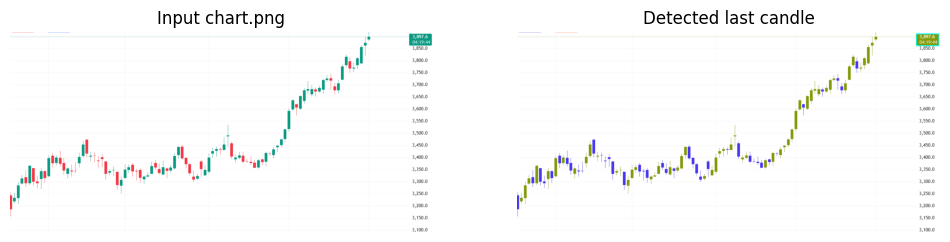

candle_type.txt → BULLISH


In [5]:
import matplotlib.pyplot as plt
import cv2

# show chart and debug side-by-side
fig, axs = plt.subplots(1,2, figsize=(12,5))
axs[0].set_title("Input chart.png")
axs[0].imshow(cv2.cvtColor(cv2.imread(CHART_PATH), cv2.COLOR_BGR2RGB))
axs[0].axis("off")

axs[1].set_title("Detected last candle")
axs[1].imshow(cv2.cvtColor(cv2.imread(DBG_IMG), cv2.COLOR_BGR2RGB))
axs[1].axis("off")
plt.show()

# read back candle_type.txt
with open(OUT_TXT) as f:
    print("candle_type.txt →", f.read().strip())
